# 16 – LSMC Counterfactual Duration Sweep

Tests three revenue-component counterfactuals to confirm **which driver flattens the 1h→2h
LSMC duration premium** (currently 1.08× vs Modo's observed 1.52×).

| Case | delta_imb_scale | DC/QR modes |
|---|---|---|
| **no_imbalance** | 0 | active |
| **no_ancillary** | 1 (full) | excluded |
| **energy_only** | 0 | excluded |

Baseline (full-stack) is loaded from the nb13 sweep output — not recomputed.

**Hypothesis**: `no_imbalance` ratio ≈ WD rolling intrinsic (1.48×);  
`no_ancillary` stays flat (imbalance dominates and is MW-based);  
`energy_only` ≈ 1.45–1.55× (matches DA/WD intrinsic scaling).

In [1]:
from __future__ import annotations

import copy, json, os, pickle, sys, time
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import src.config as cfg
from src.config import ASSET, DEGRADATION, FINANCE, LSMC as LSMC_CFG, SCHWARTZ_SMITH, configure_asset_duration
from src.optimisation.dispatch import enumerate_modes
from src.optimisation.lsmc import LSMCSolver
from src.processes.ancillary import AncillaryParams
from src.processes.hpfc import HPFCParams
from src.processes.imbalance import ImbalanceParams
from src.processes.schwartz_smith import SSParams
from src.processes.simulate import PathBundle, default_params_from_config
from src.validation import validate_path_bundle

PROCESSED = PROJECT_ROOT / 'data' / 'processed'

# Extend valid durations as nb12 does
cfg.VALID_ASSET_DURATIONS_H = (0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0)

# ── Run settings — matching nb12 "medium" mode ────────────────────────────────
SEED         = int(LSMC_CFG.get('seed', 42))
DT_H         = float(LSMC_CFG.get('dt_hours', 0.5))
BWD_PATHS    = 500
FWD_PATHS    = 500
N_STEPS      = 4320          # ~90 days at HH resolution
SOH_NODES    = [1.00, 0.90, 0.82]
RIDGE_ALPHA  = 200.0
CONT_CAP     = float(LSMC_CFG.get('continuation_value_cap_gbp', 25_000_000))
FWD_WINDOW   = 16            # fixed 8-hour forward-carry window (all durations)

SWEEP_DURATIONS = [1.0, 2.0]
HORIZON_YEARS   = N_STEPS * DT_H / 8760.0
ANN             = 1.0 / HORIZON_YEARS

print(f'Project root : {PROJECT_ROOT}')
print(f'Horizon      : {N_STEPS} HH = {HORIZON_YEARS:.4f} years  →  ×{ANN:.2f} annualisation')
print(f'Durations    : {SWEEP_DURATIONS}')

Project root : g:\My Drive\Research\BESS\bess_project
Horizon      : 4320 HH = 0.2466 years  →  ×4.06 annualisation
Durations    : [1.0, 2.0]


In [ ]:
# ── Process parameters (calibrated if available, else config defaults) ────────
def _load_json_or_default(cls, default_obj, *fnames):
    for fname in fnames:
        path = PROCESSED / fname
        if path.exists():
            print(f'  Loaded calibrated {fname}')
            return cls.from_json(path)
    print(f'  Using config default for {", ".join(fnames)}')
    return default_obj

ss_def, hpfc_def, imb_def, anc_def, _bm_def = default_params_from_config()
ss_p   = _load_json_or_default(SSParams,        ss_def,   'ss_params.json')
hpfc_p = _load_json_or_default(HPFCParams,      hpfc_def, 'pca_params.json', 'hpfc_params.json')
imb_p  = _load_json_or_default(ImbalanceParams, imb_def,  'imbalance_params.json')
anc_p  = _load_json_or_default(AncillaryParams, anc_def,  'ancillary_params.json')

# ── Simulation bundle ─────────────────────────────────────────────────────────
with (PROCESSED / 'sim_bundle.pkl').open('rb') as f:
    bundle_full = pickle.load(f)
validate_path_bundle(
    bundle_full,
    forward_anchor_gbp_mwh=SCHWARTZ_SMITH['forward_anchor_gbp_mwh']
).raise_if_failed()
print(f'Bundle  : {bundle_full.n_paths} paths × {bundle_full.n_steps} steps')

# ── HPFC half-hourly anchor (same source as nb12) ─────────────────────────────
_hpfc_raw = pd.read_parquet(PROCESSED / 'hpfc.parquet')
_hpfc_raw['delivery_date'] = pd.to_datetime(_hpfc_raw['delivery_date'])
_hpfc_raw = _hpfc_raw.sort_values(['delivery_date', 'hour'])
_hourly   = _hpfc_raw['price_gbp_mwh'].to_numpy(dtype=np.float32)
_hh_raw   = np.repeat(_hourly, int(round(1.0 / DT_H)))   # 2 HH per hour
_needed   = N_STEPS + 1
if len(_hh_raw) < _needed:
    _hh_raw = np.pad(_hh_raw, (0, _needed - len(_hh_raw)), mode='edge')
HPFC_HH = np.clip(_hh_raw[:_needed], 1e-3, 500.0).astype(np.float32)
print(f'HPFC    : {len(HPFC_HH)} HH, mean £{HPFC_HH[:N_STEPS].mean():.1f}/MWh')

# ── HPFC-anchored simulation prices ──────────────────────────────────────────
_ln_P_raw      = bundle_full.ln_P_base[:, :N_STEPS + 1].astype(np.float32)
_rel           = np.exp(np.clip(_ln_P_raw - _ln_P_raw[:, :1], -3.0, 3.0))
LN_P_ANCHORED  = np.log(
    np.clip(HPFC_HH[None, :] * _rel, 1e-3, 500.0)
).astype(np.float32)
print(f'Anchored: mean £{np.exp(LN_P_ANCHORED[:, :N_STEPS]).mean():.1f}/MWh')

# ── Path splits — same seed and logic as nb12 ─────────────────────────────────
_rng    = np.random.default_rng(SEED)
BWD_IDX = _rng.choice(bundle_full.n_paths, size=BWD_PATHS, replace=False)
_pool   = np.setdiff1d(np.arange(bundle_full.n_paths), BWD_IDX)
FWD_IDX = _rng.choice(_pool, size=FWD_PATHS, replace=False)
print(f'Paths   : {BWD_PATHS} backward  |  {FWD_PATHS} forward (disjoint)')

def _slice_bundle(idx: np.ndarray) -> PathBundle:
    return PathBundle(
        chi       = bundle_full.chi[idx, :N_STEPS + 1],
        xi        = bundle_full.xi[idx, :N_STEPS + 1],
        ln_P_base = LN_P_ANCHORED[idx, :N_STEPS + 1],
        lam       = bundle_full.lam[idx, :N_STEPS + 1, :],
        delta_imb = bundle_full.delta_imb[idx, :N_STEPS + 1],
        pi_bm     = bundle_full.pi_bm[idx, :N_STEPS + 1],
        pi        = {k: v[idx, :N_STEPS + 1] for k, v in bundle_full.pi.items()},
        dt        = bundle_full.dt,
        n_paths   = len(idx),
        n_steps   = N_STEPS,
    )

BUNDLE_BWD = _slice_bundle(BWD_IDX)
BUNDLE_FWD = _slice_bundle(FWD_IDX)

In [3]:
# ── Counterfactual configurations ─────────────────────────────────────────────
COUNTERFACTUALS = {
    'no_imbalance': {
        'label':           'No imbalance (δ=0)',
        'delta_imb_scale': 0.0,
        'dc_levels':       [0.0, 0.25, 0.5],
        'qr_levels':       [0.0, 0.25],
        'note':            'DC+QR active; imbalance cashflow zeroed',
    },
    'no_ancillary': {
        'label':           'No ancillary (DA+imb)',
        'delta_imb_scale': 1.0,
        'dc_levels':       [0.0],
        'qr_levels':       [0.0],
        'note':            'Full imbalance; no DC/QR reserve modes',
    },
    'energy_only': {
        'label':           'Energy only (DA)',
        'delta_imb_scale': 0.0,
        'dc_levels':       [0.0],
        'qr_levels':       [0.0],
        'note':            'DA-only — closest to WD rolling intrinsic benchmark',
    },
}

print('Counterfactual cases:')
for key, c in COUNTERFACTUALS.items():
    n_modes = len(enumerate_modes(
        net_levels=[-1.0, -0.5, 0.0, 0.5, 1.0],
        dc_levels=c['dc_levels'],
        qr_levels=c['qr_levels'],
    ))
    print(f'  {key:15s} | δ_scale={c["delta_imb_scale"]} | {n_modes:2d} modes | {c["note"]}')

Counterfactual cases:
  no_imbalance    | δ_scale=0.0 | 18 modes | DC+QR active; imbalance cashflow zeroed
  no_ancillary    | δ_scale=1.0 |  5 modes | Full imbalance; no DC/QR reserve modes
  energy_only     | δ_scale=0.0 |  5 modes | DA-only — closest to WD rolling intrinsic benchmark


In [4]:
# ── Run engine ────────────────────────────────────────────────────────────────
# All (case × duration) tasks execute in parallel; wall-clock ≈ slowest task.
# Each solver instance is independent: separate asset config, modes, and LSMC cfg.
# Shared: BUNDLE_BWD / BUNDLE_FWD (same price paths for all cases; asset
# differences enter only via solver feasibility/SoC-grid, not the bundle).

def run_one(case_key: str, case_cfg: dict, duration_h: float) -> dict:
    t0 = time.time()

    asset = copy.deepcopy(ASSET)
    configure_asset_duration(asset, duration_h)

    n_soc = max(9, 3 * int(duration_h))   # 3 nodes/hour, min 9 (matches nb12 medium)

    lsmc_run_cfg = dict(LSMC_CFG)
    lsmc_run_cfg.update({
        'n_soc_nodes':                n_soc,
        'soh_nodes':                  SOH_NODES,
        'n_soh_nodes':                len(SOH_NODES),
        'ridge_alpha':                RIDGE_ALPHA,
        'continuation_value_cap_gbp': CONT_CAP,
        'fwd_window_hh':              FWD_WINDOW,
        'delta_imb_scale':            float(case_cfg['delta_imb_scale']),
        'da_forward_feature_mode':     'efa_blocks',
        'da_forward_feature_hh':       48,
        'imbalance_signal_lag_hh':     int(LSMC_CFG.get('imbalance_signal_lag_hh', 1)),
    })

    modes = enumerate_modes(
        net_levels=[-1.0, -0.5, 0.0, 0.5, 1.0],
        dc_levels=case_cfg['dc_levels'],
        qr_levels=case_cfg['qr_levels'],
    )

    solver = LSMCSolver(
        asset, lsmc_run_cfg, DEGRADATION, FINANCE,
        modes=modes, verbose=False,
        hpfc_params=hpfc_p,
        hpfc_curve=HPFC_HH,
    )

    policy = solver.backward(BUNDLE_BWD)
    result = solver.forward(BUNDLE_FWD, policy)

    # Annualise
    ann_value = float(np.mean(result.pv_paths)) * ANN
    bd = {k: float(np.mean(v)) * ANN / 1e6 for k, v in result.cf_breakdown.items()}

    elapsed = time.time() - t0
    print(
        f'  [{case_key} {duration_h:g}h]  '
        f'£{ann_value/1e6:.2f}m/yr  '
        f'(da={bd["da"]:+.2f}m  imb={bd["imbalance"]:+.2f}m  '
        f'dc={bd["dc"]:+.2f}m  qr={bd["qr"]:+.2f}m  costs={bd["costs"]:+.2f}m)  '
        f'{elapsed/60:.0f}min',
        flush=True,
    )

    return {
        'case':              case_key,
        'label':             case_cfg['label'],
        'duration_h':        duration_h,
        'ann_value_m':       ann_value / 1e6,
        'gbp_per_mw_year_k': ann_value / asset['power_mw'] / 1e3,
        'attr_da_m':         bd['da'],
        'attr_imb_m':        bd['imbalance'],
        'attr_dc_m':         bd['dc'],
        'attr_qr_m':         bd['qr'],
        'attr_costs_m':      bd['costs'],
        'elapsed_s':         round(elapsed, 1),
    }


tasks = [
    (case_key, case_cfg, dur)
    for case_key, case_cfg in COUNTERFACTUALS.items()
    for dur in SWEEP_DURATIONS
]
print(f'Launching {len(tasks)} tasks  '
      f'({len(COUNTERFACTUALS)} cases × {len(SWEEP_DURATIONS)} durations) in parallel...\n')

t_wall = time.time()
results_list: list[dict] = []
n_workers = min(len(tasks), os.cpu_count() or 4)
with ThreadPoolExecutor(max_workers=n_workers) as pool:
    futs = {pool.submit(run_one, ck, cc, dur): (ck, dur) for ck, cc, dur in tasks}
    for fut in as_completed(futs):
        ck, dur = futs[fut]
        try:
            results_list.append(fut.result())
        except Exception as exc:
            print(f'ERROR [{ck} {dur:g}h]: {exc}')

print(f'\nAll tasks done in {(time.time() - t_wall)/60:.1f} min')

Launching 6 tasks  (3 cases × 2 durations) in parallel...



  [no_ancillary 2h]  £1.22m/yr  (da=+1.23m  imb=+0.89m  dc=+0.00m  qr=+0.00m  costs=+0.89m)  11min
  [no_ancillary 1h]  £0.52m/yr  (da=+0.39m  imb=+0.60m  dc=+0.00m  qr=+0.00m  costs=+0.47m)  11min
  [energy_only 2h]  £1.06m/yr  (da=+1.60m  imb=+0.00m  dc=+0.00m  qr=+0.00m  costs=+0.54m)  11min
  [energy_only 1h]  £0.42m/yr  (da=+0.61m  imb=+0.00m  dc=+0.00m  qr=+0.00m  costs=+0.20m)  11min
  [no_imbalance 1h]  £1.32m/yr  (da=+0.26m  imb=+0.00m  dc=+0.76m  qr=+0.37m  costs=+0.06m)  12min
  [no_imbalance 2h]  £2.97m/yr  (da=+0.86m  imb=+0.00m  dc=+1.81m  qr=+0.52m  costs=+0.22m)  12min

All tasks done in 11.9 min


Counterfactual results — annualised £m/year (100 MW battery):
                               1h    2h  2h/1h
label                                         
Baseline (full stack, nb13)  1.26  2.76   2.19
No imbalance (δ=0)           1.32  2.97   2.24
No ancillary (DA+imb)        0.52  1.22   2.36
Energy only (DA)             0.42  1.06   2.55
WD rolling intrinsic (ref)   3.68  5.59   1.52
DA rolling intrinsic (ref)   1.69  3.21   1.90

Attribution detail (£m/year):
                label  duration_h  attr_da_m  attr_imb_m  attr_dc_m  attr_qr_m  attr_costs_m  ann_value_m
     Energy only (DA)         1.0       0.61        0.00       0.00       0.00          0.20         0.42
     Energy only (DA)         2.0       1.60        0.00       0.00       0.00          0.54         1.06
No ancillary (DA+imb)         1.0       0.39        0.60       0.00       0.00          0.47         0.52
No ancillary (DA+imb)         2.0       1.23        0.89       0.00       0.00          0.89         1.22
 

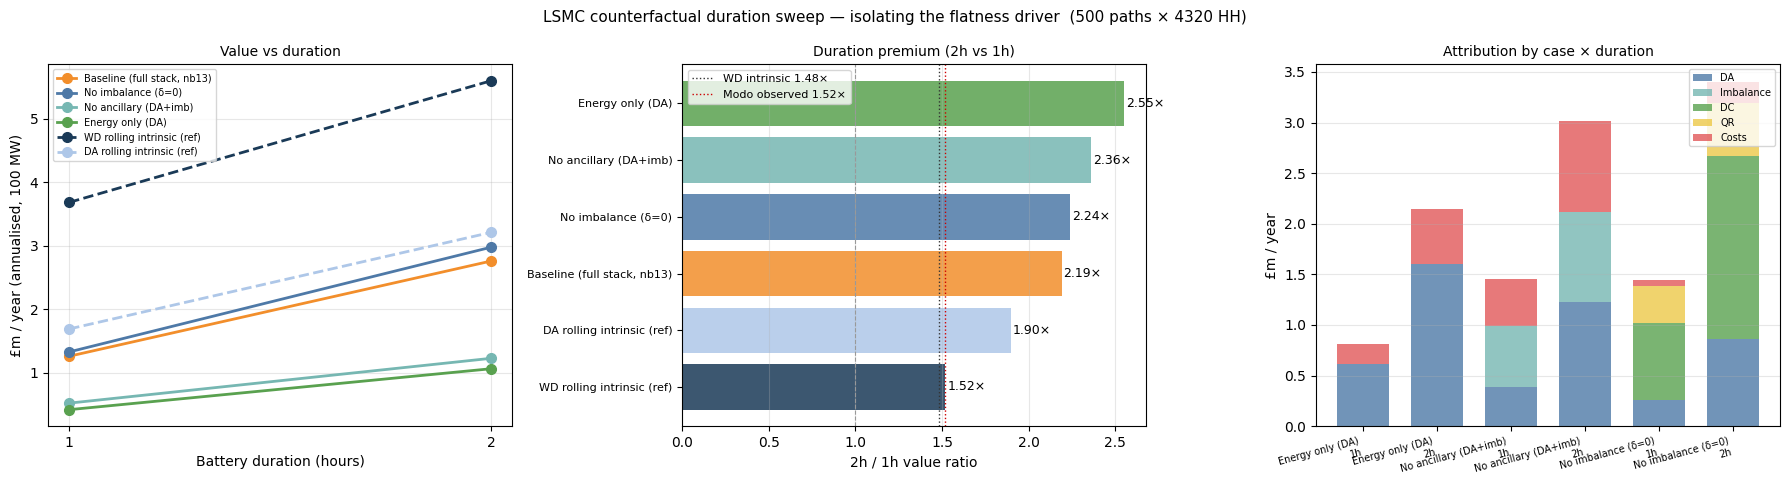

In [5]:
# ── Load baseline and rolling-intrinsic reference from nb13 output ────────────
nb13_df = pd.DataFrame(json.loads((PROCESSED / 'phase4_all_durations_comparison.json').read_text()))

ref_methods = {
    'Forward simulation (LSMC)': 'Baseline (full stack, nb13)',
    'WD rolling intrinsic':      'WD rolling intrinsic (ref)',
    'DA rolling intrinsic':      'DA rolling intrinsic (ref)',
}
ref_rows: list[dict] = []
for method, label in ref_methods.items():
    for dur in SWEEP_DURATIONS:
        row = nb13_df[(nb13_df['method'] == method) & (nb13_df['duration_h'] == dur)]
        if not row.empty:
            ref_rows.append({
                'case':      label,
                'label':     label,
                'duration_h': dur,
                'ann_value_m': float(row['value_gbp_annualized_m'].iloc[0]),
                'gbp_per_mw_year_k': float(row['gbp_per_mw_year_k'].iloc[0]),
            })

# ── Build combined pivot ──────────────────────────────────────────────────────
df_all = pd.DataFrame(results_list + ref_rows)
pivot  = df_all.pivot_table(
    index='label', columns='duration_h', values='ann_value_m', aggfunc='first'
)
pivot.columns = [f'{c:g}h' for c in pivot.columns]

if '1h' in pivot.columns and '2h' in pivot.columns:
    pivot['2h/1h'] = (pivot['2h'] / pivot['1h']).round(2)

order = (
    ['Baseline (full stack, nb13)']
    + [COUNTERFACTUALS[k]['label'] for k in COUNTERFACTUALS]
    + ['WD rolling intrinsic (ref)', 'DA rolling intrinsic (ref)']
)
pivot = pivot.reindex([l for l in order if l in pivot.index])

print('Counterfactual results — annualised £m/year (100 MW battery):')
print(pivot.round(2).to_string())

# ── Attribution table for counterfactual cases ────────────────────────────────
df_cf = pd.DataFrame(results_list)
if not df_cf.empty:
    attr_cols = ['label', 'duration_h', 'attr_da_m', 'attr_imb_m',
                 'attr_dc_m', 'attr_qr_m', 'attr_costs_m', 'ann_value_m']
    print('\nAttribution detail (£m/year):')
    print(
        df_cf[attr_cols]
        .sort_values(['label', 'duration_h'])
        .round(2)
        .to_string(index=False)
    )

# ── Save ──────────────────────────────────────────────────────────────────────
out_json = PROCESSED / 'lsmc_counterfactual_results.json'
df_cf.to_json(out_json, orient='records', indent=2)
print(f'\nSaved: {out_json}')

# ── Charts ────────────────────────────────────────────────────────────────────
COLOURS = {
    'Baseline (full stack, nb13)':  '#f28e2b',
    'No imbalance (δ=0)':           '#4e79a7',
    'No ancillary (DA+imb)':        '#76b7b2',
    'Energy only (DA)':             '#59a14f',
    'WD rolling intrinsic (ref)':   '#1a3a57',
    'DA rolling intrinsic (ref)':   '#aec7e8',
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    'LSMC counterfactual duration sweep — isolating the flatness driver  '
    f'({BWD_PATHS} paths × {N_STEPS} HH)',
    fontsize=11,
)

# ── Left: value vs duration ───────────────────────────────────────────────────
ax = axes[0]
for label in pivot.index:
    vals = [pivot.loc[label, f'{d:g}h'] if f'{d:g}h' in pivot.columns else np.nan
            for d in SWEEP_DURATIONS]
    ls = '--' if '(ref)' in label else '-'
    ax.plot(SWEEP_DURATIONS, vals, 'o' + ls, lw=2, ms=7,
            color=COLOURS.get(label, '#888'), label=label)
ax.set_xticks(SWEEP_DURATIONS)
ax.set_xlabel('Battery duration (hours)')
ax.set_ylabel('£m / year (annualised, 100 MW)')
ax.set_title('Value vs duration', fontsize=10)
ax.legend(fontsize=7)
ax.grid(alpha=0.3)

# ── Centre: 2h/1h ratio horizontal bar ───────────────────────────────────────
ax = axes[1]
if '2h/1h' in pivot.columns:
    ratios = pivot['2h/1h'].dropna().sort_values()
    bar_colours = [COLOURS.get(l, '#888') for l in ratios.index]
    ax.barh(range(len(ratios)), ratios.values, color=bar_colours, alpha=0.85)
    ax.set_yticks(range(len(ratios)))
    ax.set_yticklabels(ratios.index, fontsize=8)
    for i, v in enumerate(ratios.values):
        ax.text(v + 0.01, i, f'{v:.2f}×', va='center', fontsize=9)
    ax.axvline(1.0,  color='#999999', lw=0.8, ls='--')
    ax.axvline(1.48, color='#333333', lw=1.0, ls=':', label='WD intrinsic 1.48×')
    ax.axvline(1.52, color='#cc0000', lw=1.0, ls=':', label='Modo observed 1.52×')
    ax.set_xlabel('2h / 1h value ratio')
    ax.set_title('Duration premium (2h vs 1h)', fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(axis='x', alpha=0.3)

# ── Right: attribution stacked bar for 1h and 2h (counterfactual cases) ───────
ax = axes[2]
if not df_cf.empty:
    attr_keys  = ['attr_da_m', 'attr_imb_m', 'attr_dc_m', 'attr_qr_m', 'attr_costs_m']
    attr_labels = ['DA', 'Imbalance', 'DC', 'QR', 'Costs']
    attr_colours = ['#4e79a7', '#76b7b2', '#59a14f', '#edc948', '#e15759']

    # One group per (case × duration), stacked bars
    df_plot = df_cf.sort_values(['label', 'duration_h']).reset_index(drop=True)
    x_labels = [f"{r['label']}\n{r['duration_h']:g}h" for _, r in df_plot.iterrows()]
    x = np.arange(len(x_labels))
    bot_pos = np.zeros(len(df_plot))
    bot_neg = np.zeros(len(df_plot))
    for col, lbl, col_c in zip(attr_keys, attr_labels, attr_colours):
        vals = df_plot[col].to_numpy(dtype=float) if col in df_plot.columns else np.zeros(len(df_plot))
        # costs are stored as negative; plot below zero
        pos = np.where(vals >= 0, vals, 0.0)
        neg = np.where(vals < 0, vals, 0.0)
        ax.bar(x, pos, bottom=bot_pos, color=col_c, alpha=0.8, label=lbl, width=0.7)
        ax.bar(x, neg, bottom=bot_neg, color=col_c, alpha=0.8, width=0.7)
        bot_pos = bot_pos + pos
        bot_neg = bot_neg + neg

    ax.axhline(0, color='#555', lw=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, fontsize=7, rotation=15, ha='right')
    ax.set_ylabel('£m / year')
    ax.set_title('Attribution by case × duration', fontsize=10)
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(axis='y', alpha=0.3)

fig.tight_layout()
out_png = PROCESSED / 'lsmc_counterfactual_results.png'
fig.savefig(out_png, dpi=140, bbox_inches='tight')
print(f'Saved: {out_png}')
plt.show()